In [1]:
import json
import numpy as np
import cv2
import os

os.makedirs('data', exist_ok=True)

# Generate dummy image
img = np.random.randint(50, 100, (1024, 1024, 3), dtype=np.uint8)
img[:, :, 1] = np.random.randint(100, 150, (1024, 1024))
cv2.imwrite('data/post_img.png', img)

# Generate dummy JSON
fake_json = {
    "features": {
        "xy": [
            {
                "properties": {"subtype": "destroyed"},
                "wkt": "POLYGON ((100 100, 300 100, 300 300, 100 300, 100 100))"
            },
            {
                "properties": {"subtype": "no-damage"},
                "wkt": "POLYGON ((500 500, 700 500, 700 600, 500 600, 500 500))"
            }
        ]
    }
}

with open('data/post_label.json', 'w') as f:
    json.dump(fake_json, f)

print("Dummy data generated! You can now run the visualization script.")


Dummy data generated! You can now run the visualization script.


In [7]:
pip install shapely


  Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.8 kB)
Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl (1.6 MB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


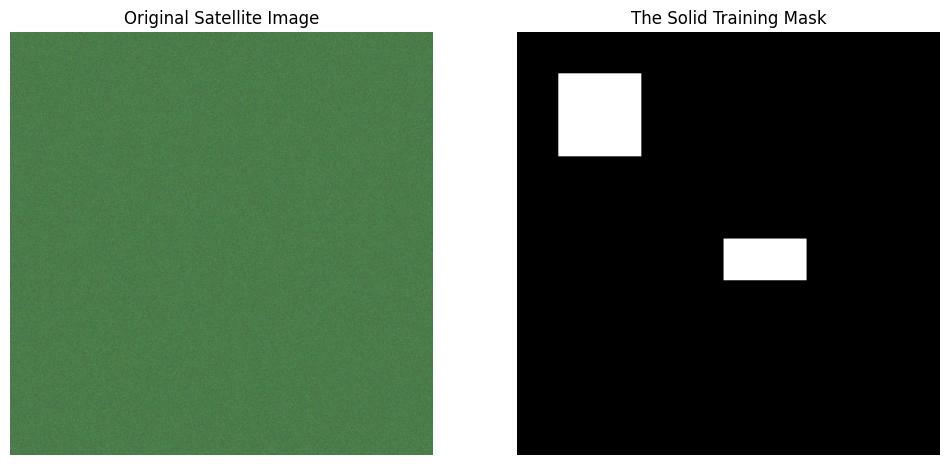

In [8]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from shapely import wkt

# 1. Tell Python where your files are
image_path = 'data/post_img.png'
json_path = 'data/post_label.json'

# 2. Load the image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Fix colors so it looks right on screen

# 3. Create a blank black canvas (the exact same size as the image)
mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8) 

# 4. Open the JSON file and read the text
with open(json_path, 'r') as f:
    label_data = json.load(f)

# 5. Loop through every building in the JSON and draw it solid white on the black canvas
for feature in label_data['features']['xy']:
    polygon_wkt = feature['wkt']          # Get the text coordinates
    poly = wkt.loads(polygon_wkt)         # Convert text to a math shape
    coords = np.array(poly.exterior.coords, dtype=np.int32) # Get the exact pixel points
    
    # Fill the shape with solid white (255)
    cv2.fillPoly(mask, [coords], color=255)

# 6. Show the original image and the new mask side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Satellite Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("The Solid Training Mask")
plt.axis('off')

plt.show()

In [11]:
pip install torch torchvision segmentation-models-pytorch

  Using cached torch-2.10.0-2-cp312-none-macosx_11_0_arm64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached segmentation_models_pytorch-0.5.0-py3-none-any.whl.metadata (17 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached huggingface_hub-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached timm-1.0.25-py3-none-any.whl.metadata (38 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached hf_xet-1.4.2-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached

In [12]:
import torch
import segmentation_models_pytorch as smp

# 1. Define the U-Net Model
# We use MobileNetV2 as the 'encoder' because it is extremely fast and lightweight 
# (perfect for edge deployment in disaster zones).
model = smp.Unet(
    encoder_name="mobilenet_v2",    # The lightweight backbone
    encoder_weights="imagenet",     # Pre-trained on millions of images for better accuracy
    in_channels=3,                  # We are feeding it standard RGB colored images
    classes=1,                      # We want 1 output mask (damage vs. no damage)
)

# 2. Test the model with a fake image tensor to make sure it works
# Creating a dummy tensor: (Batch Size of 1, 3 Color Channels, 256x256 pixels)
dummy_image = torch.randn(1, 3, 256, 256) 
predicted_mask = model(dummy_image)

print("AI Model architecture built successfully!")
print(f"Input Image Shape: {dummy_image.shape}")
print(f"Output Mask Shape: {predicted_mask.shape}")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

AI Model architecture built successfully!
Input Image Shape: torch.Size([1, 3, 256, 256])
Output Mask Shape: torch.Size([1, 1, 256, 256])


In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class DisasterDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        # Get a list of all image file names
        self.images = os.listdir(image_dir)
        
        # Standard transformations: resize to 256x256 and convert to PyTorch tensors
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Get the file paths
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name) # Assuming mask has same name
        
        # 2. Open the images
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L") # 'L' means Grayscale (1 channel)
        
        # 3. Apply the resizes and conversions
        image = self.transform(image)
        mask = self.transform(mask)
        
        return image, mask

print("Custom PyTorch Dataset class is ready!")

In [2]:
import os
import json
import cv2
import numpy as np
from shapely import wkt

# Define where your files are
img_dir = '/Users/smaryanarang/Desktop/disaster-recovery-ai/data/images'
json_dir = '/Users/smaryanarang/Desktop/disaster-recovery-ai/data/labels '
mask_dir = '/Users/smaryanarang/Desktop/disaster-recovery-ai/data/masks'

# Make sure the masks folder exists
os.makedirs(mask_dir, exist_ok=True)

# Get a list of all the JSON files
json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
print(f"Found {len(json_files)} JSON labels to convert...")

converted_count = 0

for json_filename in json_files:
    # Get the matching image name (replace .json with .png)
    img_filename = json_filename.replace('.json', '.png')
    
    img_path = os.path.join(img_dir, img_filename)
    json_path = os.path.join(json_dir, json_filename)
    mask_path = os.path.join(mask_dir, img_filename) # Save mask as PNG
    
    # Check if the image actually exists
    if not os.path.exists(img_path):
        continue
        
    # Read the original image just to get its size (width and height)
    img = cv2.imread(img_path)
    if img is None: continue
    h, w = img.shape[:2]
    
    # Create a blank black canvas
    mask = np.zeros((h, w), dtype=np.uint8)
    
    # Read the JSON
    with open(json_path, 'r') as f:
        label_data = json.load(f)
        
    # Draw the solid white buildings on the black canvas
    if 'xy' in label_data['features']:
        for feature in label_data['features']['xy']:
            polygon_wkt = feature['wkt']
            try:
                poly = wkt.loads(polygon_wkt)
                coords = np.array(poly.exterior.coords, dtype=np.int32)
                cv2.fillPoly(mask, [coords], color=255)
            except Exception as e:
                pass # Skip broken polygons
                
    # Save the final black-and-white mask
    cv2.imwrite(mask_path, mask)
    converted_count += 1

print(f"Success! Converted {converted_count} JSON files into solid PNG training masks.")

Found 50 JSON labels to convert...
Success! Converted 50 JSON files into solid PNG training masks.


In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import segmentation_models_pytorch as smp

# --- 1. SET UP THE DATA LOADER ---
class DisasterDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])
        
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        
        return self.transform(image), self.transform(mask)

# Make sure these match your actual folder paths!
dataset = DisasterDataset(image_dir='data/images', mask_dir='data/masks')
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# --- 2. SET UP THE MODEL & MATH ---
model = smp.Unet(encoder_name="mobilenet_v2", encoder_weights="imagenet", in_channels=3, classes=1)
loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- 3. THE TRAINING LOOP ---
print("Starting training...")
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for images, masks in dataloader:
        optimizer.zero_grad()           # Clear old memory
        predictions = model(images)     # AI makes a guess
        loss = loss_fn(predictions, masks) # Calculate how wrong it was
        loss.backward()                 # Learn from the mistake
        optimizer.step()                # Update the AI's brain
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

print("Training complete! Your AI has officially learned from the data.")

Starting training...
Epoch 1/5 | Loss: 0.8715
Epoch 2/5 | Loss: 0.8289
Epoch 3/5 | Loss: 0.7626
Epoch 4/5 | Loss: 0.7008
Epoch 5/5 | Loss: 0.6045
Training complete! Your AI has officially learned from the data.


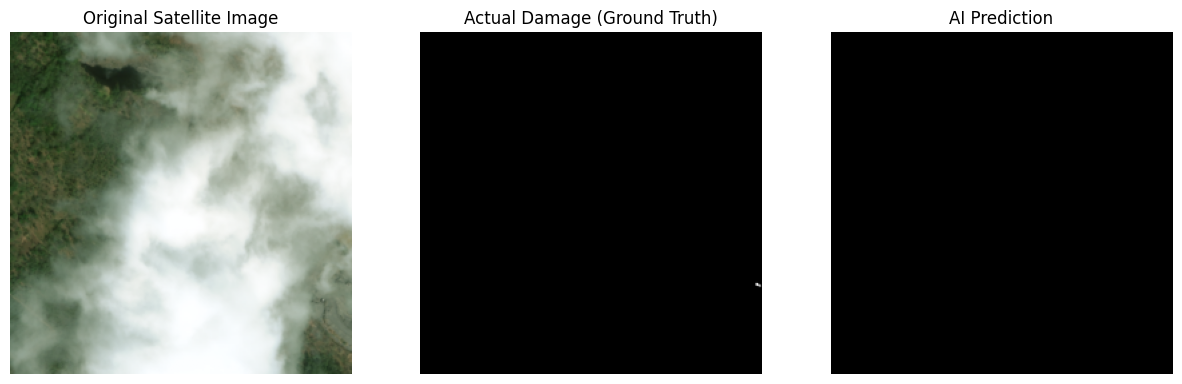

In [4]:
import matplotlib.pyplot as plt

# 1. Put the model in "Test Mode" (locks the brain so it stops learning and just predicts)
model.eval()

# 2. Grab a single batch of images from your dataset
images, true_masks = next(iter(dataloader))

# 3. Ask the AI to guess where the damage is
with torch.no_grad():
    predicted_masks = model(images)

# 4. Clean up the AI's math into a black-and-white picture
predicted_masks = torch.sigmoid(predicted_masks) # Squish numbers between 0 and 1
predicted_masks = (predicted_masks > 0.5).float()  # Anything over 50% confidence is marked as "Damaged"

# 5. Plot the results for the very first image in the batch
plt.figure(figsize=(15, 5))

# Plot 1: Original Image
plt.subplot(1, 3, 1)
img_to_show = images[0].permute(1, 2, 0).numpy() # Convert PyTorch format to standard image format
plt.imshow(img_to_show)
plt.title("Original Satellite Image")
plt.axis('off')

# Plot 2: The Ground Truth (What it SHOULD look like)
plt.subplot(1, 3, 2)
true_mask_to_show = true_masks[0].squeeze().numpy()
plt.imshow(true_mask_to_show, cmap='gray')
plt.title("Actual Damage (Ground Truth)")
plt.axis('off')

# Plot 3: The AI's Prediction
plt.subplot(1, 3, 3)
pred_mask_to_show = predicted_masks[0].squeeze().numpy()
plt.imshow(pred_mask_to_show, cmap='gray')
plt.title("AI Prediction")
plt.axis('off')

plt.show()